In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/df_clean.csv')

# Drop the rows with NaNs in our lag features before doing ML
# We lose about 1,600 rows (1% of the data)
df_ml = df.dropna(subset=['temp_lag_7']).copy()

print(f"✅ Data loaded for Anomaly Detection: {df_ml.shape}")

✅ Data loaded for Anomaly Detection: (143611, 57)


In [5]:
# Select core weather features to scan for anomalies
features = ['temperature_celsius', 'humidity', 'wind_kph', 'pressure_mb']

# Initialize the model 
iso_forest = IsolationForest(contamination=0.01, random_state=42)

# Fit and predict (-1 means Anomaly, 1 means Normal)
print("Training Isolation Forest...")
df_ml['anomaly_flag'] = iso_forest.fit_predict(df_ml[features])

anomaly_counts = df_ml['anomaly_flag'].value_counts()
print(f"\nNormal records: {anomaly_counts[1]:,}")
print(f"Anomalies detected: {anomaly_counts[-1]:,}")

Training Isolation Forest...

Normal records: 142,174
Anomalies detected: 1,437


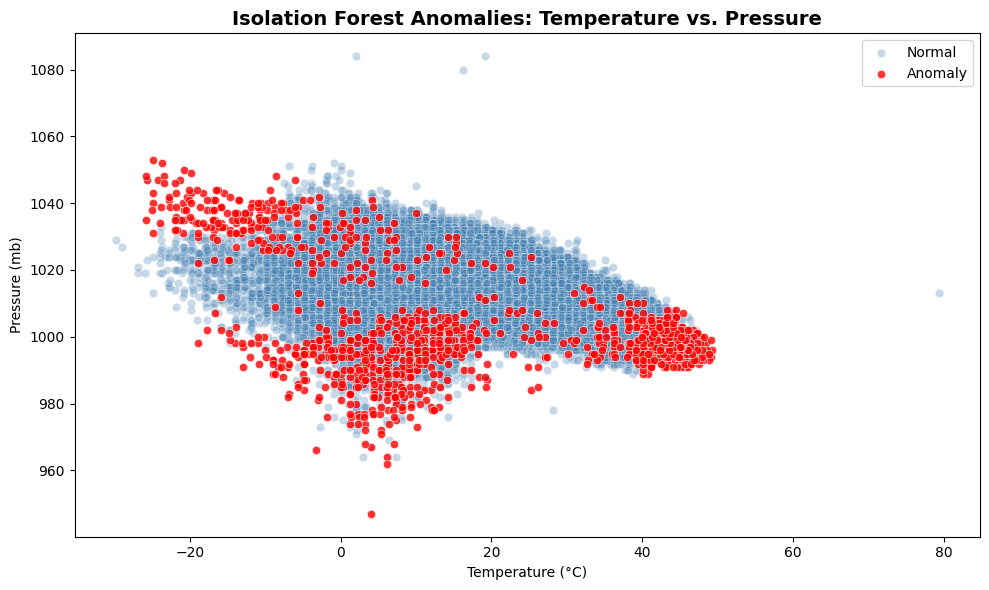

✅ Saved: 10_anomaly_scatter.png


In [6]:
# Plot Temperature vs Pressure, colored by Anomaly Flag
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_ml[df_ml['anomaly_flag'] == 1], 
    x='temperature_celsius', y='pressure_mb', 
    color='steelblue', alpha=0.3, label='Normal'
)

sns.scatterplot(
    data=df_ml[df_ml['anomaly_flag'] == -1], 
    x='temperature_celsius', y='pressure_mb', 
    color='red', alpha=0.8, label='Anomaly'
)

plt.title('Isolation Forest Anomalies: Temperature vs. Pressure', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)')
plt.ylabel('Pressure (mb)')
plt.legend()
plt.tight_layout()

plt.savefig('../outputs/10_anomaly_scatter.png', dpi=150)
plt.show()
print("✅ Saved: 10_anomaly_scatter.png")

In [8]:
anomalies = df_ml[df_ml['anomaly_flag'] == -1]

print("Top 5 Countries with the most anomalies:")
print(anomalies['country'].value_counts().head(5))

print("\nAnomalies by Season:")
print(anomalies['season'].value_counts())

df_ml.to_csv('../data/df_model_ready.csv', index=False)
print("\n✅ Saved: data/df_model_ready.csv")

Top 5 Countries with the most anomalies:
country
Kuwait          172
Iceland         142
Iraq            119
Saudi Arabia     92
Qatar            85
Name: count, dtype: int64

Anomalies by Season:
season
Summer    656
Winter    459
Spring    173
Autumn    149
Name: count, dtype: int64

✅ Saved: data/df_model_ready.csv


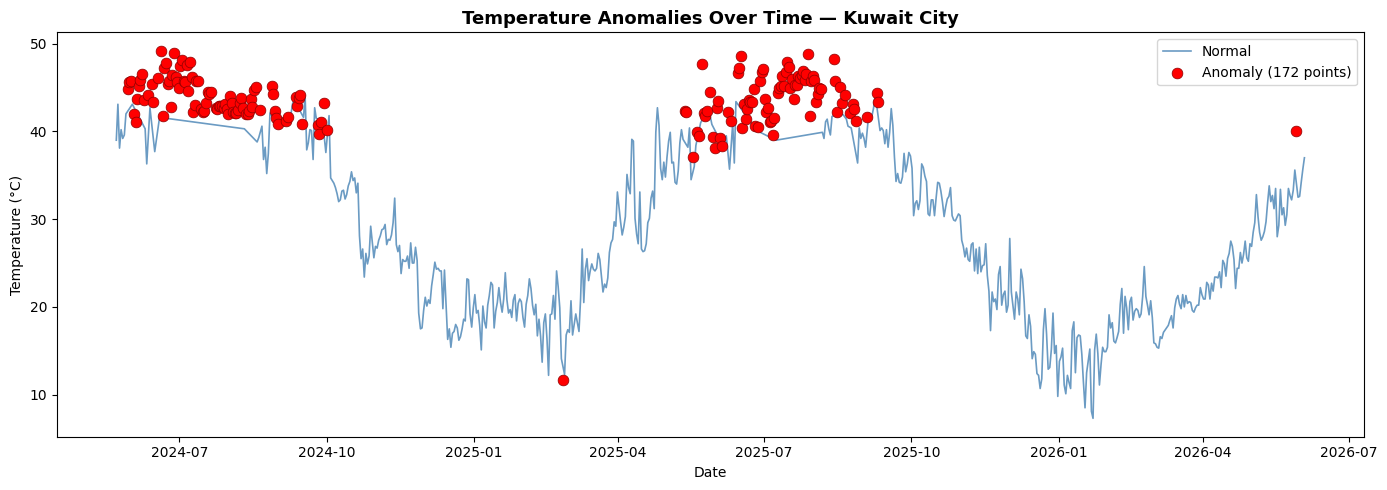

✅ Saved: 11_anomaly_timeseries.png  |  City: Kuwait City


In [9]:
# Time series: anomaly points marked on one city's temperature history
top_city = anomalies['location_name'].value_counts().idxmax()
city_data = df_ml[df_ml['location_name'] == top_city].copy()
city_data['last_updated'] = pd.to_datetime(city_data['last_updated'])
city_data = city_data.sort_values('last_updated')

city_normal   = city_data[city_data['anomaly_flag'] ==  1]
city_anom     = city_data[city_data['anomaly_flag'] == -1]

plt.figure(figsize=(14, 5))
plt.plot(city_normal['last_updated'], city_normal['temperature_celsius'],
         color='steelblue', linewidth=1.2, alpha=0.8, label='Normal', zorder=2)
plt.scatter(city_anom['last_updated'], city_anom['temperature_celsius'],
            color='red', s=60, zorder=4, edgecolors='darkred', linewidths=0.5,
            label=f'Anomaly ({len(city_anom)} points)')

plt.title(f'Temperature Anomalies Over Time — {top_city}', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/11_anomaly_timeseries.png', dpi=150)
plt.show()
print(f"✅ Saved: 11_anomaly_timeseries.png  |  City: {top_city}")